# 518880: 2-Tick Spread And Asymmetric Information

目标：研究 `spread == 2 tick` 是否对应更高的不对称信息风险。

这里把“不对称信息增加”先 operationalize 成几个可观测代理变量：
- 未来短 horizon 内 `mid` 的绝对变动是否更大
- 下一次 `mid` move 是否更快到来
- 下一次 `mid` move 的方向是否更容易被当前盘口失衡解释
- 2-tick 状态是否伴随更薄的盘口和更偏的主动成交

研究框架：
1. 先构造逐秒盘口 / 主动成交面板。
2. 对比 `spread == 1` 与 `spread == 2` 两类状态的未来波动代理变量。
3. 额外看 `2-tick` 刚出现时的 entry event，避免长时间停留在同一状态带来的重复采样。

说明：若 `base_tool` 导入失败，通常是当前 notebook kernel 与 `/home/jovyan/work/base_demo` 下扩展模块 ABI 不匹配，需要切换到可用内核。

In [9]:
from __future__ import annotations

import io
import math
import sys
from contextlib import redirect_stdout
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

try:
    from IPython.display import Markdown, display
except Exception:
    display = print
    Markdown = lambda x: x

for candidate in [Path('/home/jovyan/work/base_demo'), Path('/home/jovyan/base_demo')]:
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.append(str(candidate))

import base_tool  # type: ignore

INSTRUMENT_ID = '518880'
START_YMD = '20251201'
END_YMD = '20260425'
TICK_SIZE = 0.001
TIMEZONE = 'Asia/Shanghai'
HORIZONS = [1, 5, 10, 30]
TIME_BUCKET_MINUTES = 30

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.6g}')

In [10]:
def candidate_dates(start_ymd: str = START_YMD, end_ymd: str = END_YMD) -> list[str]:
    return [d.strftime('%Y%m%d') for d in pd.date_range(start=start_ymd, end=end_ymd, freq='B')]


def in_regular_session(ts: pd.Timestamp) -> bool:
    hm = ts.hour * 100 + ts.minute
    if 930 <= hm < 1130:
        return True
    if 1300 <= hm < 1500:
        return True
    return ts.strftime('%H:%M:%S') == '15:00:00'


def bucket_label(ts: pd.Timestamp, minutes: int = TIME_BUCKET_MINUTES) -> str:
    if ts.strftime('%H:%M:%S') == '15:00:00':
        ts = ts - pd.Timedelta(seconds=1)
    start = ts.floor(f'{minutes}min')
    end = start + pd.Timedelta(minutes=minutes)
    return f"{start.strftime('%H:%M')}-{end.strftime('%H:%M')}"


def load_snaps(trade_ymd: str) -> list[dict]:
    with redirect_stdout(io.StringIO()):
        snap_list = base_tool.snap_list_load(INSTRUMENT_ID, trade_ymd)
    return snap_list if isinstance(snap_list, list) else []


def valid_dates(dates: list[str] | None = None) -> list[str]:
    dates = candidate_dates() if dates is None else dates
    valid = []
    for trade_ymd in dates:
        snaps = load_snaps(trade_ymd)
        if snaps:
            valid.append(trade_ymd)
    return valid


def sum_volume(trades: list[list[float]] | None) -> float:
    trades = trades or []
    return float(sum(volume for _, volume in trades))


def sum_turnover(trades: list[list[float]] | None) -> float:
    trades = trades or []
    return float(sum(price * volume for price, volume in trades))


def depth_sum(book: list[list[float]] | None, levels: int) -> float:
    book = book or []
    return float(sum(volume for _, volume in book[:levels]))


def imbalance(bid_depth: float, ask_depth: float) -> float:
    denom = bid_depth + ask_depth
    if denom <= 0:
        return math.nan
    return float((bid_depth - ask_depth) / denom)


def build_day_panel(trade_ymd: str) -> pd.DataFrame:
    rows: list[dict] = []
    for snap in load_snaps(trade_ymd):
        bid_book = snap.get('bid_book') or []
        ask_book = snap.get('ask_book') or []
        if not bid_book or not ask_book:
            continue

        best_bid, best_bid_vol = bid_book[0]
        best_ask, best_ask_vol = ask_book[0]
        bid_l3 = depth_sum(bid_book, 3)
        ask_l3 = depth_sum(ask_book, 3)
        bid_l5 = depth_sum(bid_book, 5)
        ask_l5 = depth_sum(ask_book, 5)
        buy_trade = snap.get('buy_trade') or []
        sell_trade = snap.get('sell_trade') or []
        ts = (
            pd.to_datetime(int(snap['time_mark']), unit='ms', utc=True)
            .tz_convert(TIMEZONE)
            .tz_localize(None)
        )
        if not in_regular_session(ts):
            continue

        rows.append(
            {
                'trade_ymd': trade_ymd,
                'timestamp': ts,
                'time_hms': ts.strftime('%H:%M:%S'),
                'best_bid': float(best_bid),
                'best_ask': float(best_ask),
                'mid': float((best_bid + best_ask) / 2.0),
                'spread_ticks': float((best_ask - best_bid) / TICK_SIZE),
                'bid_l1': float(best_bid_vol),
                'ask_l1': float(best_ask_vol),
                'bid_l3': bid_l3,
                'ask_l3': ask_l3,
                'bid_l5': bid_l5,
                'ask_l5': ask_l5,
                'l1_imbalance': imbalance(float(best_bid_vol), float(best_ask_vol)),
                'l3_imbalance': imbalance(bid_l3, ask_l3),
                'l5_imbalance': imbalance(bid_l5, ask_l5),
                'buy_vol': sum_volume(buy_trade),
                'sell_vol': sum_volume(sell_trade),
                'buy_turnover': sum_turnover(buy_trade),
                'sell_turnover': sum_turnover(sell_trade),
                'num_trades': float(snap.get('num_trades', 0)),
            }
        )

    df = pd.DataFrame(rows).sort_values('timestamp').reset_index(drop=True)
    if df.empty:
        return df

    df['spread_ticks'] = df['spread_ticks'].round().astype(int)
    df['mid_move_half_tick'] = np.rint(df['mid'].diff().fillna(0.0) / (TICK_SIZE / 2.0)).astype(int)
    df['abs_mid_move_tick'] = np.abs(df['mid'].diff().fillna(0.0) / TICK_SIZE)
    df['active_vol'] = df['buy_vol'] + df['sell_vol']
    df['active_turnover'] = df['buy_turnover'] + df['sell_turnover']
    df['net_active_vol'] = df['buy_vol'] - df['sell_vol']
    df['net_active_turnover'] = df['buy_turnover'] - df['sell_turnover']
    df['active_vol_imbalance'] = np.where(
        df['active_vol'] > 0,
        df['net_active_vol'] / df['active_vol'],
        0.0,
    )
    df['l1_depth'] = df['bid_l1'] + df['ask_l1']
    df['l5_depth'] = df['bid_l5'] + df['ask_l5']
    df['prev_spread_ticks'] = df['spread_ticks'].shift(1)
    df['is_spread2_entry'] = (df['spread_ticks'] == 2) & (df['prev_spread_ticks'] != 2)
    df['is_spread1_entry'] = (df['spread_ticks'] == 1) & (df['prev_spread_ticks'] != 1)
    df['bucket_30m'] = df['timestamp'].map(bucket_label)
    df['hour_minute'] = df['timestamp'].dt.strftime('%H:%M')
    return df


def build_panel(dates: list[str]) -> pd.DataFrame:
    frames = []
    for trade_ymd in dates:
        day_df = build_day_panel(trade_ymd)
        if not day_df.empty:
            frames.append(day_df)
    if not frames:
        return pd.DataFrame()
    panel = pd.concat(frames, ignore_index=True)

    for horizon in HORIZONS:
        lead_mid = panel.groupby('trade_ymd')['mid'].shift(-horizon)
        panel[f'fwd_mid_move_tick_{horizon}s'] = (lead_mid - panel['mid']) / TICK_SIZE
        panel[f'fwd_abs_mid_move_tick_{horizon}s'] = panel[f'fwd_mid_move_tick_{horizon}s'].abs()
        panel[f'fwd_move_ge_1tick_{horizon}s'] = (panel[f'fwd_abs_mid_move_tick_{horizon}s'] >= 1.0).astype(float)

    panel['next_move_half_tick'] = math.nan
    panel['time_to_next_mid_move'] = math.nan
    for trade_ymd, idx in panel.groupby('trade_ymd').groups.items():
        day_idx = list(idx)
        day_df = panel.loc[day_idx].reset_index()
        next_move = np.full(len(day_df), np.nan)
        wait_time = np.full(len(day_df), np.nan)
        next_nonzero = None
        next_direction = math.nan
        for pos in range(len(day_df) - 1, -1, -1):
            curr_move = day_df.loc[pos, 'mid_move_half_tick']
            if next_nonzero is not None:
                wait_time[pos] = float(next_nonzero - pos)
                next_move[pos] = next_direction
            if curr_move != 0:
                next_nonzero = pos
                next_direction = float(curr_move)
        panel.loc[day_df['index'], 'next_move_half_tick'] = next_move
        panel.loc[day_df['index'], 'time_to_next_mid_move'] = wait_time
    return panel


In [11]:
dates = valid_dates()
panel = build_panel(dates)

headline = pd.DataFrame([
    {
        'trade_days': int(panel['trade_ymd'].nunique()),
        'rows': int(len(panel)),
        'date_start': panel['trade_ymd'].min(),
        'date_end': panel['trade_ymd'].max(),
        'spread_1_ratio': (panel['spread_ticks'] == 1).mean(),
        'spread_2_ratio': (panel['spread_ticks'] == 2).mean(),
        'spread_ge_3_ratio': (panel['spread_ticks'] >= 3).mean(),
        'spread2_entry_count': int(panel['is_spread2_entry'].sum()),
    }
])

display(Markdown('## Sample Overview'))
display(headline)
display(panel.head())

## Sample Overview

,trade_days,rows,date_start,date_end,spread_1_ratio,spread_2_ratio,spread_ge_3_ratio,spread2_entry_count
0,49,705331,20251201,20260423,0.926452,0.0646491,0.00889937,32627


,trade_ymd,timestamp,time_hms,best_bid,best_ask,mid,spread_ticks,bid_l1,ask_l1,bid_l3,ask_l3,bid_l5,ask_l5,l1_imbalance,l3_imbalance,l5_imbalance,buy_vol,sell_vol,buy_turnover,sell_turnover,num_trades,mid_move_half_tick,abs_mid_move_tick,active_vol,active_turnover,net_active_vol,net_active_turnover,active_vol_imbalance,l1_depth,l5_depth,prev_spread_ticks,is_spread2_entry,is_spread1_entry,bucket_30m,hour_minute,fwd_mid_move_tick_1s,fwd_abs_mid_move_tick_1s,fwd_move_ge_1tick_1s,fwd_mid_move_tick_5s,fwd_abs_mid_move_tick_5s,fwd_move_ge_1tick_5s,fwd_mid_move_tick_10s,fwd_abs_mid_move_tick_10s,fwd_move_ge_1tick_10s,fwd_mid_move_tick_30s,fwd_abs_mid_move_tick_30s,fwd_move_ge_1tick_30s,next_move_half_tick,time_to_next_mid_move
0,20251201,2025-12-01 09:30:00,09:30:00,9.146,9.147,9.1465,1,"168,700","13,400",1.1504e+06,"137,600",1.1568e+06,"507,019",0.852828,0.786335,0.390536,4.2916e+06,4.2916e+06,3.9251e+07,3.9251e+07,"1,745",0,0,8.5832e+06,7.85019e+07,0,0,0,"182,100",1.66382e+06,NaN,False,True,09:30-10:00,09:30,13,13,1,8,8,1,16,16,1,12,12,1,26,1
1,20251201,2025-12-01 09:30:01,09:30:01,9.159,9.16,9.1595,1,"78,300","143,800","205,800","175,100","554,700","460,000",-0.294912,0.0805986,0.0933281,"857,319","15,800",7.84609e+06,"144,591","1,969",26,13,"873,119",7.99068e+06,"841,519",7.7015e+06,0.963808,"222,100",1.0147e+06,1,False,False,09:30-10:00,09:30,-0.5,0.5,0,-3,3,1,1,1,0,-1,1,1,-1,1
2,20251201,2025-12-01 09:30:02,09:30:02,9.158,9.16,9.159,2,"154,700","143,700","487,000","445,000","835,900","729,900",0.0368633,0.0450644,0.067697,100,"128,200",916,1.17413e+06,"1,984",-1,0.5,"128,300",1.17505e+06,"-128,100",-1.17322e+06,-0.998441,"298,400",1.5658e+06,1,True,False,09:30-10:00,09:30,-3.5,3.5,1,3.5,3.5,1,1,1,1,1,1,1,-7,1
3,20251201,2025-12-01 09:30:03,09:30:03,9.153,9.158,9.1555,5,"262,600","1,900","632,300","155,800",1.49438e+06,"458,000",0.985633,0.604619,0.530829,"1,000","224,400","9,160",2.05482e+06,"2,039",-7,3.5,"225,400",2.06398e+06,"-223,400",-2.04566e+06,-0.991127,"264,500",1.95238e+06,2,False,False,09:30-10:00,09:30,1,1,1,7,7,1,3.5,3.5,1,5,5,1,2,1
4,20251201,2025-12-01 09:30:04,09:30:04,9.153,9.16,9.1565,7,"64,300","137,300","444,000","170,600",1.54838e+06,"455,500",-0.362103,0.444842,0.545382,"7,300","255,500","66,864.2",2.33859e+06,"2,102",2,1,"262,800",2.40546e+06,"-248,200",-2.27173e+06,-0.944444,"201,600",2.00388e+06,5,False,False,09:30-10:00,09:30,-2,2,1,6,6,1,0.5,0.5,0,3.5,3.5,1,-4,1


### 表格说明: `Sample Overview`

变量定义：
- `trade_days`: 样本里实际有数据的交易日数量。
- `rows`: 进入分析面板的总秒数，已经过滤到常规交易时段。
- `date_start` / `date_end`: 样本起止日期。
- `spread_1_ratio`: 全部样本秒里，`spread == 1 tick` 的占比。
- `spread_2_ratio`: 全部样本秒里，`spread == 2 tick` 的占比。
- `spread_ge_3_ratio`: 全部样本秒里，`spread >= 3 tick` 的占比。
- `spread2_entry_count`: `spread` 从非 2 tick 切换到 2 tick 的事件次数。

怎么分析结果：
- 先看 `spread_2_ratio`，确认 2-tick 在这只 ETF 上到底是常见状态还是稀有状态。
- 再看 `spread2_entry_count`，确认后面做 event study 时样本是否足够。
- `panel.head()` 不是统计结果，而是原始分析面板的前几行，用来核对字段构造是否符合预期。

## 2-Tick And Time Of Day

,bucket_30m,total_seconds,spread2_seconds,spread2_entries,spread1_seconds,active_seconds,avg_abs_move_5s,spread2_ratio,spread1_ratio,spread2_entry_rate_per_hour,active_ratio,entry_share
0,09:30-10:00,88200,7324,5452,79241,87039,0.964144,0.0830385,0.898424,222.531,0.986837,0.167101
1,13:30-14:00,88200,6549,4686,80977,82131,0.814399,0.0742517,0.918107,191.265,0.93119,0.143623
2,10:30-11:00,88200,6060,4221,81411,81414,0.785028,0.0687075,0.923027,172.286,0.923061,0.129371
3,14:00-14:30,88200,5982,4261,81595,81713,0.728481,0.0678231,0.925113,173.918,0.926451,0.130597
4,11:00-11:30,88200,5447,3816,82156,78506,0.71165,0.0617574,0.931474,155.755,0.890091,0.116958
5,10:00-10:30,88200,5414,3852,82037,83380,0.683345,0.0613832,0.930125,157.224,0.945351,0.118062
6,14:30-15:00,87931,4764,3554,82599,85590,0.65003,0.0541788,0.939362,145.505,0.973377,0.108928
7,13:00-13:30,88200,4059,2785,83439,79717,0.434014,0.0460204,0.94602,113.673,0.903821,0.0853588


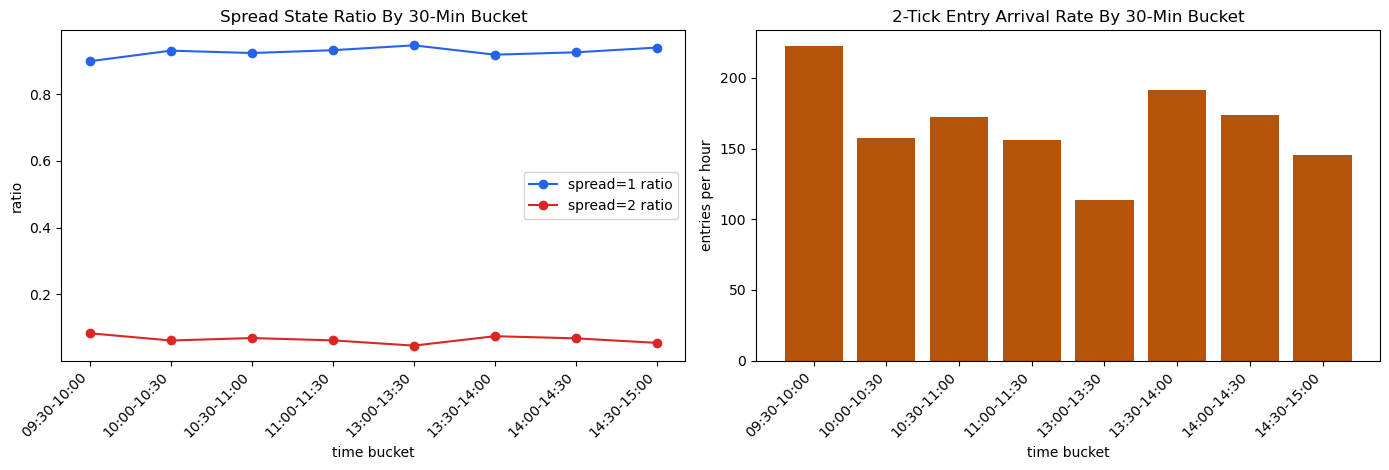

In [12]:
time_relation = (
    panel.groupby('bucket_30m', sort=False)
    .agg(
        total_seconds=('bucket_30m', 'size'),
        spread2_seconds=('spread_ticks', lambda x: (x == 2).sum()),
        spread2_entries=('is_spread2_entry', 'sum'),
        spread1_seconds=('spread_ticks', lambda x: (x == 1).sum()),
        active_seconds=('active_vol', lambda x: (x > 0).sum()),
        avg_abs_move_5s=('fwd_abs_mid_move_tick_5s', 'mean'),
    )
    .reset_index()
)
time_relation['spread2_ratio'] = time_relation['spread2_seconds'] / time_relation['total_seconds']
time_relation['spread1_ratio'] = time_relation['spread1_seconds'] / time_relation['total_seconds']
time_relation['spread2_entry_rate_per_hour'] = time_relation['spread2_entries'] / (time_relation['total_seconds'] / 3600.0)
time_relation['active_ratio'] = time_relation['active_seconds'] / time_relation['total_seconds']
time_relation['entry_share'] = time_relation['spread2_entries'] / time_relation['spread2_entries'].sum()

display(Markdown('## 2-Tick And Time Of Day'))
display(time_relation.sort_values('spread2_ratio', ascending=False).reset_index(drop=True))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
x = np.arange(len(time_relation))

axes[0].plot(x, time_relation['spread1_ratio'], marker='o', label='spread=1 ratio', color='#2563eb')
axes[0].plot(x, time_relation['spread2_ratio'], marker='o', label='spread=2 ratio', color='#dc2626')
axes[0].set_title('Spread State Ratio By 30-Min Bucket')
axes[0].set_xlabel('time bucket')
axes[0].set_ylabel('ratio')
axes[0].set_xticks(x)
axes[0].set_xticklabels(time_relation['bucket_30m'], rotation=45, ha='right')
axes[0].legend()

axes[1].bar(x, time_relation['spread2_entry_rate_per_hour'], color='#b45309')
axes[1].set_title('2-Tick Entry Arrival Rate By 30-Min Bucket')
axes[1].set_xlabel('time bucket')
axes[1].set_ylabel('entries per hour')
axes[1].set_xticks(x)
axes[1].set_xticklabels(time_relation['bucket_30m'], rotation=45, ha='right')

fig.tight_layout()


### 表格说明: `2-Tick And Time Of Day`

变量定义：
- `bucket_30m`: 30 分钟时间桶，例如 `09:30-10:00`。
- `total_seconds`: 这个时间桶里累计有多少个样本秒。
- `spread2_seconds`: 这个时间桶里，`spread == 2` 的秒数。
- `spread2_entries`: 这个时间桶里，`spread` 新切到 2 tick 的次数。
- `spread1_seconds`: 这个时间桶里，`spread == 1` 的秒数。
- `active_seconds`: 这个时间桶里，主动成交量大于 0 的秒数。
- `avg_abs_move_5s`: 从这个时间桶里的样本秒出发，未来 5 秒 `mid` 绝对变动的均值，单位是 tick。
- `spread2_ratio`: `spread2_seconds / total_seconds`，表示这个时段处于 2-tick 状态的占比。
- `spread1_ratio`: `spread1_seconds / total_seconds`，表示这个时段处于 1-tick 状态的占比。
- `spread2_entry_rate_per_hour`: 把 `spread2_entries` 换算成每小时平均会出现多少次 2-tick entry。
- `active_ratio`: `active_seconds / total_seconds`，表示这个时段有成交的活跃度。
- `entry_share`: 全部 2-tick entry 中，有多少比例发生在这个时间桶。

怎么分析结果：
- `spread2_ratio` 高，说明这个时段更容易处在 2 tick。
- `spread2_entry_rate_per_hour` 高，说明这个时段更容易新出现 2 tick，而不是前面状态的延续。
- 如果 `spread2_ratio` 和 `active_ratio` 一起高，可能是活跃交易时段伴随更高报价风险。
- 如果 `spread2_ratio` 高但 `avg_abs_move_5s` 不高，更像流动性结构差异，不一定是信息风险上升。
- 如果 2-tick 明显集中在开盘或尾盘，后续比较 `spread=1` 与 `spread=2` 时要控制时间段。

In [13]:
def summarize_state(df: pd.DataFrame, label: str) -> pd.DataFrame:
    row = {
        'label': label,
        'samples': int(len(df)),
        'avg_l1_depth': df['l1_depth'].mean(),
        'avg_l5_depth': df['l5_depth'].mean(),
        'avg_abs_l1_imbalance': df['l1_imbalance'].abs().mean(),
        'avg_abs_active_vol_imbalance': df['active_vol_imbalance'].abs().mean(),
        'median_time_to_next_mid_move': df['time_to_next_mid_move'].median(),
    }
    for horizon in HORIZONS:
        row[f'avg_fwd_abs_mid_move_{horizon}s'] = df[f'fwd_abs_mid_move_tick_{horizon}s'].mean()
        row[f'p_fwd_move_ge_1tick_{horizon}s'] = df[f'fwd_move_ge_1tick_{horizon}s'].mean()
    return pd.DataFrame([row])


state_summary = pd.concat(
    [
        summarize_state(panel[panel['spread_ticks'] == 1], 'all spread=1'),
        summarize_state(panel[panel['spread_ticks'] == 2], 'all spread=2'),
        summarize_state(panel[panel['is_spread1_entry']], 'entry spread=1'),
        summarize_state(panel[panel['is_spread2_entry']], 'entry spread=2'),
    ],
    ignore_index=True,
)

display(Markdown('## State Comparison'))
display(state_summary)

## State Comparison

,label,samples,avg_l1_depth,avg_l5_depth,avg_abs_l1_imbalance,avg_abs_active_vol_imbalance,median_time_to_next_mid_move,avg_fwd_abs_mid_move_1s,p_fwd_move_ge_1tick_1s,avg_fwd_abs_mid_move_5s,p_fwd_move_ge_1tick_5s,avg_fwd_abs_mid_move_10s,p_fwd_move_ge_1tick_10s,avg_fwd_abs_mid_move_30s,p_fwd_move_ge_1tick_30s
0,all spread=1,653455,"403,542",3.65083e+06,0.537758,0.720304,4,0.235249,0.104004,0.661495,0.2802,1.00212,0.387422,1.93106,0.577229
1,all spread=2,45599,"352,472",2.82144e+06,0.486342,0.693107,1,0.635235,0.169214,1.32639,0.410842,1.88574,0.530801,3.37591,0.703108
2,entry spread=1,33643,"211,956",2.63068e+06,0.680167,0.687605,2,0.576429,0.233927,1.28973,0.464495,1.85128,0.568231,3.36852,0.714443
3,entry spread=2,32627,"370,283",2.87465e+06,0.485227,0.689073,1,0.643201,0.167009,1.32072,0.404083,1.87184,0.526711,3.34669,0.699298


### 表格说明: `State Comparison`

变量定义：
- `label`: 样本定义。
- `all spread=1`: 所有 `spread == 1` 的秒。
- `all spread=2`: 所有 `spread == 2` 的秒。
- `entry spread=1`: `spread` 刚切到 1 tick 的那些秒。
- `entry spread=2`: `spread` 刚切到 2 tick 的那些秒。
- `samples`: 这组样本里一共有多少个秒级观测。
- `avg_l1_depth`: 一档总深度均值，等于 `bid_l1 + ask_l1`。
- `avg_l5_depth`: 五档总深度均值，等于 `bid_l5 + ask_l5`。
- `avg_abs_l1_imbalance`: 一档盘口失衡绝对值均值，失衡定义为 `(bid_l1 - ask_l1) / (bid_l1 + ask_l1)`。
- `avg_abs_active_vol_imbalance`: 主动成交失衡绝对值均值，定义为 `abs((buy_vol - sell_vol) / (buy_vol + sell_vol))`。
- `median_time_to_next_mid_move`: 从当前秒到下一次 `mid` 变化要等几秒，取中位数。
- `avg_fwd_abs_mid_move_{1,5,10,30}s`: 未来对应 horizon 内，`mid` 相对当前的绝对变动均值，单位 tick。
- `p_fwd_move_ge_1tick_{1,5,10,30}s`: 未来对应 horizon 内，`mid` 至少变动 1 tick 的概率。

怎么分析结果：
- 比 `all spread=2` 和 `all spread=1`，看 2-tick 状态本身是否更薄、更偏、更容易马上动。
- 比 `entry spread=2` 和 `entry spread=1`，看刚出现 2 tick 时是否更像一个事件触发点。
- 如果 2-tick 的 `avg_l1_depth` 更低、`avg_abs_l1_imbalance` 更高、`median_time_to_next_mid_move` 更低，而且未来 move 指标更高，这组证据才比较一致地支持信息风险更高。
- 如果只看到深度更低，但未来波动并没更强，那更像流动性短暂变薄。

In [14]:
all_compare = pd.DataFrame({
    'horizon_s': HORIZONS,
    'spread1_avg_abs_move': [panel.loc[panel['spread_ticks'] == 1, f'fwd_abs_mid_move_tick_{h}s'].mean() for h in HORIZONS],
    'spread2_avg_abs_move': [panel.loc[panel['spread_ticks'] == 2, f'fwd_abs_mid_move_tick_{h}s'].mean() for h in HORIZONS],
    'spread1_p_ge_1tick': [panel.loc[panel['spread_ticks'] == 1, f'fwd_move_ge_1tick_{h}s'].mean() for h in HORIZONS],
    'spread2_p_ge_1tick': [panel.loc[panel['spread_ticks'] == 2, f'fwd_move_ge_1tick_{h}s'].mean() for h in HORIZONS],
})
all_compare['avg_abs_move_ratio_2_vs_1'] = all_compare['spread2_avg_abs_move'] / all_compare['spread1_avg_abs_move']
all_compare['p_ge_1tick_ratio_2_vs_1'] = all_compare['spread2_p_ge_1tick'] / all_compare['spread1_p_ge_1tick']

entry_compare = pd.DataFrame({
    'horizon_s': HORIZONS,
    'spread1_entry_avg_abs_move': [panel.loc[panel['is_spread1_entry'], f'fwd_abs_mid_move_tick_{h}s'].mean() for h in HORIZONS],
    'spread2_entry_avg_abs_move': [panel.loc[panel['is_spread2_entry'], f'fwd_abs_mid_move_tick_{h}s'].mean() for h in HORIZONS],
    'spread1_entry_p_ge_1tick': [panel.loc[panel['is_spread1_entry'], f'fwd_move_ge_1tick_{h}s'].mean() for h in HORIZONS],
    'spread2_entry_p_ge_1tick': [panel.loc[panel['is_spread2_entry'], f'fwd_move_ge_1tick_{h}s'].mean() for h in HORIZONS],
})
entry_compare['entry_avg_abs_move_ratio_2_vs_1'] = entry_compare['spread2_entry_avg_abs_move'] / entry_compare['spread1_entry_avg_abs_move']
entry_compare['entry_p_ge_1tick_ratio_2_vs_1'] = entry_compare['spread2_entry_p_ge_1tick'] / entry_compare['spread1_entry_p_ge_1tick']

display(Markdown('## Forward Move Comparison: All States'))
display(all_compare)

display(Markdown('## Forward Move Comparison: Entry Events'))
display(entry_compare)

## Forward Move Comparison: All States

,horizon_s,spread1_avg_abs_move,spread2_avg_abs_move,spread1_p_ge_1tick,spread2_p_ge_1tick,avg_abs_move_ratio_2_vs_1,p_ge_1tick_ratio_2_vs_1
0,1,0.235249,0.635235,0.104004,0.169214,2.70026,1.627
1,5,0.661495,1.32639,0.2802,0.410842,2.00514,1.46625
2,10,1.00212,1.88574,0.387422,0.530801,1.88175,1.37008
3,30,1.93106,3.37591,0.577229,0.703108,1.74822,1.21807


## Forward Move Comparison: Entry Events

,horizon_s,spread1_entry_avg_abs_move,spread2_entry_avg_abs_move,spread1_entry_p_ge_1tick,spread2_entry_p_ge_1tick,entry_avg_abs_move_ratio_2_vs_1,entry_p_ge_1tick_ratio_2_vs_1
0,1,0.576429,0.643201,0.233927,0.167009,1.11584,0.713937
1,5,1.28973,1.32072,0.464495,0.404083,1.02403,0.86994
2,10,1.85128,1.87184,0.568231,0.526711,1.01111,0.926931
3,30,3.36852,3.34669,0.714443,0.699298,0.993521,0.978802


### 表格说明: `Forward Move Comparison: All States` 和 `Entry Events`

变量定义：
- `horizon_s`: 观察未来价格变化的时间窗口，单位秒。
- `spread1_avg_abs_move` / `spread2_avg_abs_move`: 在全部 `spread=1` 或 `spread=2` 样本上，未来 `horizon_s` 秒内 `mid` 绝对变动的均值，单位 tick。
- `spread1_p_ge_1tick` / `spread2_p_ge_1tick`: 在全部 `spread=1` 或 `spread=2` 样本上，未来 `horizon_s` 秒内 `mid` 至少变动 1 tick 的概率。
- `avg_abs_move_ratio_2_vs_1`: `spread2_avg_abs_move / spread1_avg_abs_move`。
- `p_ge_1tick_ratio_2_vs_1`: `spread2_p_ge_1tick / spread1_p_ge_1tick`。
- `spread1_entry_avg_abs_move` / `spread2_entry_avg_abs_move`: 只在 entry event 上做同样的未来绝对变动比较。
- `spread1_entry_p_ge_1tick` / `spread2_entry_p_ge_1tick`: 只在 entry event 上做同样的未来至少 1 tick move 概率比较。
- `entry_avg_abs_move_ratio_2_vs_1`: `spread2_entry_avg_abs_move / spread1_entry_avg_abs_move`。
- `entry_p_ge_1tick_ratio_2_vs_1`: `spread2_entry_p_ge_1tick / spread1_entry_p_ge_1tick`。

怎么分析结果：
- 关键先看 ratio 列。大于 1，表示 2-tick 比 1-tick 更容易对应更大的未来 move。
- 如果 `all states` 和 `entry events` 两张表都显示 ratio 明显大于 1，结论更稳。
- 如果只有 `entry events` 更强，说明真正有信息的不是处于 2 tick 很久，而是 2 tick 刚出现的那一刻。
- 如果短 horizon 很强、长 horizon 回落，说明 2-tick 更像短时微观结构信号，而不是持续性信息状态。

## 2-Tick Entry: Does Quote Imbalance Explain The Next Move?

,l1_imbalance_bucket,samples,mean_l1_imbalance,median_wait,next_up_ratio,move_ge_1tick_5s,abs_move_5s
0,"(-1.001, -0.568]",6526,-0.792054,1,0.380478,0.473031,1.5115
1,"(-0.568, -0.178]",6525,-0.367321,1,0.462222,0.366897,1.21021
2,"(-0.178, 0.19]",6525,0.00756591,1,0.505134,0.351877,1.19036
3,"(0.19, 0.574]",6525,0.380205,1,0.563065,0.372107,1.22884
4,"(0.574, 1.0]",6526,0.795945,1,0.63316,0.456482,1.46266


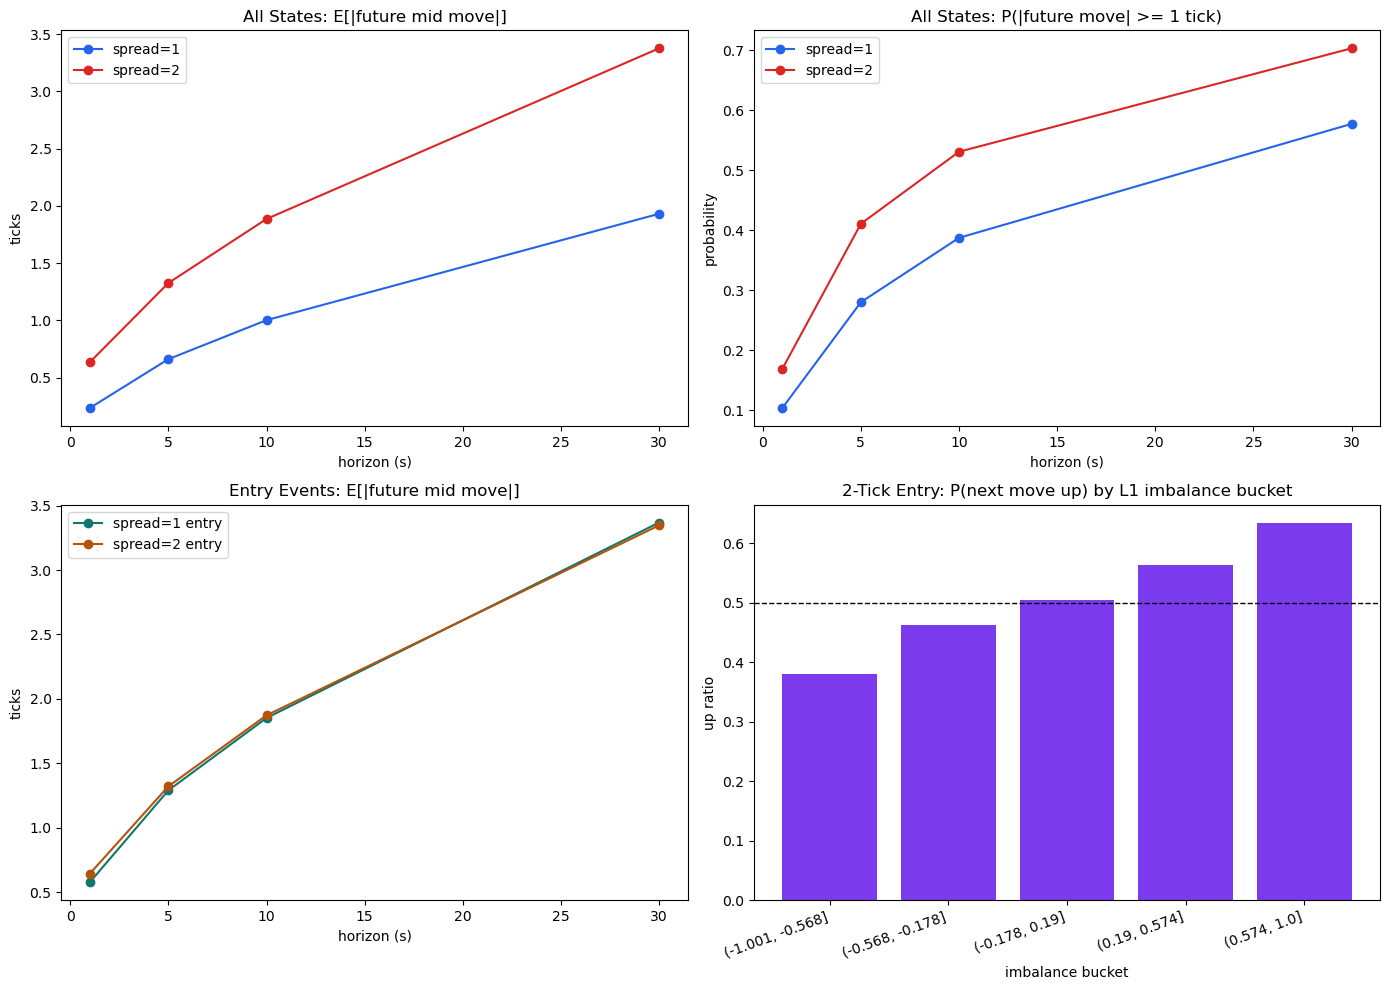

In [15]:
spread2_entry = panel.loc[panel['is_spread2_entry']].copy()
spread2_entry['l1_imbalance_bucket'] = pd.qcut(
    spread2_entry['l1_imbalance'],
    q=5,
    duplicates='drop',
)
imbalance_view = (
    spread2_entry.groupby('l1_imbalance_bucket', observed=False)
    .agg(
        samples=('l1_imbalance', 'size'),
        mean_l1_imbalance=('l1_imbalance', 'mean'),
        median_wait=('time_to_next_mid_move', 'median'),
        next_up_ratio=('next_move_half_tick', lambda x: (x > 0).mean()),
        move_ge_1tick_5s=('fwd_move_ge_1tick_5s', 'mean'),
        abs_move_5s=('fwd_abs_mid_move_tick_5s', 'mean'),
    )
    .reset_index()
)

display(Markdown('## 2-Tick Entry: Does Quote Imbalance Explain The Next Move?'))
display(imbalance_view)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(all_compare['horizon_s'], all_compare['spread1_avg_abs_move'], marker='o', label='spread=1', color='#2563eb')
axes[0, 0].plot(all_compare['horizon_s'], all_compare['spread2_avg_abs_move'], marker='o', label='spread=2', color='#dc2626')
axes[0, 0].set_title('All States: E[|future mid move|]')
axes[0, 0].set_xlabel('horizon (s)')
axes[0, 0].set_ylabel('ticks')
axes[0, 0].legend()

axes[0, 1].plot(all_compare['horizon_s'], all_compare['spread1_p_ge_1tick'], marker='o', label='spread=1', color='#2563eb')
axes[0, 1].plot(all_compare['horizon_s'], all_compare['spread2_p_ge_1tick'], marker='o', label='spread=2', color='#dc2626')
axes[0, 1].set_title('All States: P(|future move| >= 1 tick)')
axes[0, 1].set_xlabel('horizon (s)')
axes[0, 1].set_ylabel('probability')
axes[0, 1].legend()

axes[1, 0].plot(entry_compare['horizon_s'], entry_compare['spread1_entry_avg_abs_move'], marker='o', label='spread=1 entry', color='#0f766e')
axes[1, 0].plot(entry_compare['horizon_s'], entry_compare['spread2_entry_avg_abs_move'], marker='o', label='spread=2 entry', color='#b45309')
axes[1, 0].set_title('Entry Events: E[|future mid move|]')
axes[1, 0].set_xlabel('horizon (s)')
axes[1, 0].set_ylabel('ticks')
axes[1, 0].legend()

axes[1, 1].bar(np.arange(len(imbalance_view)), imbalance_view['next_up_ratio'], color='#7c3aed')
axes[1, 1].axhline(0.5, color='black', linestyle='--', linewidth=1)
axes[1, 1].set_title('2-Tick Entry: P(next move up) by L1 imbalance bucket')
axes[1, 1].set_xlabel('imbalance bucket')
axes[1, 1].set_ylabel('up ratio')
axes[1, 1].set_xticks(np.arange(len(imbalance_view)))
axes[1, 1].set_xticklabels([str(x) for x in imbalance_view['l1_imbalance_bucket']], rotation=20, ha='right')

fig.tight_layout()

### 表格说明: `2-Tick Entry: Does Quote Imbalance Explain The Next Move?`

变量定义：
- `l1_imbalance_bucket`: 把 `spread2_entry` 样本按一档失衡 `l1_imbalance` 从低到高分成若干分位桶。
- `samples`: 每个失衡桶里的样本数量。
- `mean_l1_imbalance`: 这个桶里一档失衡的平均值。
- `median_wait`: 这个桶里从 entry 到下一次 `mid` move 的等待时间中位数。
- `next_up_ratio`: 这个桶里下一次 `mid` move 向上的比例。
- `move_ge_1tick_5s`: 这个桶里未来 5 秒 `mid` 至少变动 1 tick 的概率。
- `abs_move_5s`: 这个桶里未来 5 秒 `mid` 绝对变动均值，单位 tick。

怎么分析结果：
- 这张表不是在问 2-tick 有没有风险，而是在问 2-tick 刚出现后，盘口偏向能不能解释下一跳方向和速度。
- 如果 `mean_l1_imbalance` 从负到正时，`next_up_ratio` 也单调上升，说明一档失衡对下一跳方向有解释力。
- 如果失衡越极端，`median_wait` 越短、`abs_move_5s` 越大，说明 2-tick entry 下的盘口偏置更接近临门一脚。
- 如果各桶之间差异很弱，说明 2-tick 本身可能只是更宽的价差状态，但方向信息并不集中在 L1 盘口。

## 如何解释

如果 `spread == 2` 的以下指标系统性高于 `spread == 1`，可以把它当成“2-tick 状态更像信息风险上升”的证据：
- `avg_fwd_abs_mid_move_*` 更高
- `p_fwd_move_ge_1tick_*` 更高
- `median_time_to_next_mid_move` 更低
- `avg_abs_l1_imbalance` 更高，且在 `spread2_entry` 下对 `next_up_ratio` 有更强分层

如果只看到更低深度、但未来 move 并没有更快/更大，那么更可能是“流动性暂时变薄”，不一定是不对称信息。

时间维度的解读：
- `spread2_ratio` 高，表示这个时段更容易处在 2-tick 状态。
- `spread2_entry_rate_per_hour` 高，表示这个时段更容易新出现 2-tick，而不只是前面状态的延续。
- 如果两者都集中在少数时段，需要先排除开盘/尾盘的制度性流动性变化，再谈不对称信息。

建议下一步：
- 按时段拆开看，避免开盘和尾盘驱动整体结论。
- 过滤掉无成交秒，再看一次，避免纯挂单调整噪声。
- 在 `spread2_entry` 上继续控制 `l1_depth`、`active_vol` 后，看 2-tick 本身是否仍保留增量解释力。